<a href="https://colab.research.google.com/github/chomingi-25/2026_tues_bigdatacomputing_class/blob/main/%EB%8B%A4%EC%A4%91_%ED%8A%B9%EC%84%B1_%ED%9A%8C%EA%B7%80_%EB%AA%A8%EB%8D%B8_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EA%B5%AC%EC%B6%95_%EB%B0%8F_Streamlit_%EC%9B%B9_%EC%84%9C%EB%B9%84%EC%8A%A4_%EB%B0%B0%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0단계
- 실습 환경 구축

In [ ]:
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.9 MB/s eta 0:00:00


## 1단계
- 데이터 준비 및 소규모 훈련 샘플링
- 파이프라인 기반 모델 3종 학습 및 저장

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# 데이터 로드
url="https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df=pd.read_csv(url)
df.columns = df.columns.str.strip()
df=df.dropna()
features=['Adult mortality', 'BMI', 'GDP', 'Alcohol']
target='Life expectancy'
X=df[features]
y=df[target]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=50)
X_train_small=X_train.sample(n=50, random_state=50)
y_train_small=y_train.loc[X_train_small.index]
# 모델 생성
models={
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Poly": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3)),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3)),
        ("model", Ridge(alpha=1.0))
    ])
}
# 모델 학습
trained_models={}
for name, model in models.items():
  model.fit(X_train, y_train)
  trained_models[name]=model
# 성능 비교 데이터 생성
results=[]
for name, model in trained_models.items():
  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)
  train_r2=r2_score(y_train, train_pred)
  test_r2=r2_score(y_train, train_pred)
  test_r2=r2_score(y_test, test_pred)
  train_mse=mean_squared_error(y_train, train_pred)
  test_mse=mean_squared_error(y_test, test_pred)
  if name=="Linear":
    complexity=X_train_small.shape[1]
  else:
    complexity=model.named_steps["poly"].fit_transform(X_train_small).shape[1]
  results.append([
      name,
      train_r2,
      test_r2,
      train_mse,
      test_mse,
      complexity
  ])
results_df=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Train MSE",
        "Test MSE",
        "Complexity"
    ]
)
# payload로 묶어서 저장
payload={
    "models" : trained_models,
    "results_df": results_df,
    "features" : features,
    "X_train": X_train,
    "X_test" : X_test
}
joblib.dump(
    payload,
    "life_expectancy_models.pkl"
)
print("life_expectancy_models.pkl 저장 완료")

life_expectancy_models.pkl 저장 완료


## 2단계
- 모델 성능 비교

=== 모델 성능 비교 ===


,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.6587,0.6243,24.4468,24.4468,4
1,Poly,0.8120,0.7830,14.1198,14.1198,4
2,Ridge,0.8120,0.7832,14.1074,14.1074,4


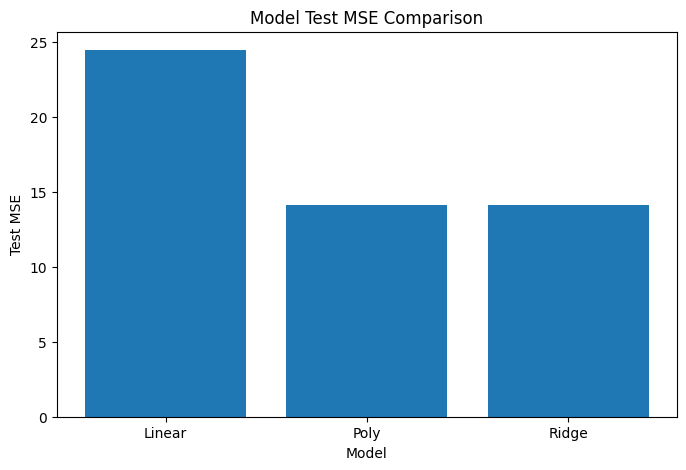


=== 최고 성능 모델 ===
모델 : Ridge
Test R2 : 0.7832
Test MSE : 14.1074
Complexity : 4


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 로드
url="https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df=pd.read_csv(url)
df=df.dropna()
X=df[[
    "Adult mortality",
    "BMI",
    "GDP",
    "Alcohol"
]]
y=df["Life expectancy"]

# 2. 데이터 분할
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=50)

# 3. 모델 생성
linear_model=Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
poly_model=Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", LinearRegression())
])
ridge_model=Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("model", Ridge(alpha=1.0))
])
# 4. 모델 성능 비교
models={
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}
results=[]
for name, model in models.items():
  model.fit(X_train, y_train)
  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)
  train_r2=r2_score(y_train, train_pred)
  test_r2=r2_score(y_test, test_pred)
  train_mse=mean_squared_error(y_train, train_pred)
  test_mse=mean_squared_error(y_test, test_pred)
  complexity=X.shape[-1]
  results.append({
      "Model": name,
      "Train R2": round(train_r2, 4),
      "Test R2": round(test_r2, 4),
      "Train MSE": round(test_mse, 4),
      "Test MSE": round(test_mse, 4),
      "Complexity": complexity
  })
result_df=pd.DataFrame(results)
print("=== 모델 성능 비교 ===")
display(result_df)
plt.figure(figsize=(8, 5))
plt.bar(
    result_df["Model"],
    result_df["Test MSE"]
)
plt.title("Model Test MSE Comparison")
plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.show()
best_idx=result_df["Test R2"].idxmax()
best_model=result_df.loc[best_idx]
print()
print("=== 최고 성능 모델 ===")
print("모델 :", best_model["Model"])
print("Test R2 :", best_model["Test R2"])
print("Test MSE :", best_model["Test MSE"])
print("Complexity :", best_model["Complexity"])

## 3단계
- app.py 실행

In [3]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

st.set_page_config(
    page_title="Life Expectancy Prediction",
    layout="centered"
)
# 저장된 pkl 데이터 로드
def load_saved_data():
  return joblib.load("life_expectancy_models.pkl")
data=load_saved_data()
models=data["models"]
results_df=data["results_df"]
features=data["features"]
X_train=data["X_train"]
X_test=data["X_test"]
st.title("Life Expectancy Prediction")
st.markdown(
    "Linear, Poly, Ridge 회귀 모델을 실시간으로 비교하고 테스트합니다."
)

# 원본 데이터 다시 로드
df=pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv")
df=df.dropna()

# 사용할 특성 선택
X=df[["Adult mortality", "BMI", "GDP", "Alcohol"]]

# Sidebar 설정
st.sidebar.header("모델 선택 및 데이터 입력")
selected_model_name=st.sidebar.selectbox("예측에 사용할 모델 선택", list(models.keys()))
current_pipeline=models[selected_model_name]
adult=st.sidebar.slider(
    "Adult mortality",
    float(X["Adult mortality"].min()),
    float(X["Adult mortality"].max()),
    float(X["Adult mortality"].mean())
)
bmi=st.sidebar.slider(
    "BMI",
    float(X["BMI"].min()),
    float(X["BMI"].max()),
    float(X["BMI"].mean())
)
gdp=st.sidebar.slider(
    "GDP",
    float(X["GDP"].min()),
    float(X["GDP"].max()),
    float(X["GDP"].mean())
)
alcohol=st.sidebar.slider(
    "Alcohol",
    float(X["Alcohol"].min()),
    float(X["Alcohol"].max()),
    float(X["Alcohol"].mean())
)
input_df=pd.DataFrame({
    'Adult mortality':[adult],
    'BMI':[bmi],
    'GDP':[gdp],
    'Alcohol':[alcohol]
})
prediction=current_pipeline.predict(input_df)[0]
st.subheader("선택 모델 : {}".format(selected_model_name))
st.success("예상 기대수명 : {:.2f} 세".format(prediction))
# 성능 비교
st.subheader("모델 성능 비교")
st.dataframe(results_df)
fig, ax=plt.subplots()
ax.bar(
    results_df["Model"],
    results_df["Test R2"]
)
ax.set_title("Test R2 Comparison")
st.pyplot(fig)

Writing app.py


## 4단계
- ngrok 연결

In [4]:
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os

ngrok.kill()
ngrok.set_auth_token("3Dw1lJLpfOQWowerEZaVV7EPgLo_511PeWA4FgnT4YWE4LU36")
os.system("streamlit run app.py --server.address 127.0.0.1 &")
public_url=ngrok.connect(8501)
print("아래 링크를 클릭하세요:\n{}".format(public_url))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.5 MB/s eta 0:00:00
아래 링크를 클릭하세요:
NgrokTunnel: "https://snack-headfirst-unsalted.ngrok-free.dev" -> "http://localhost:8501"


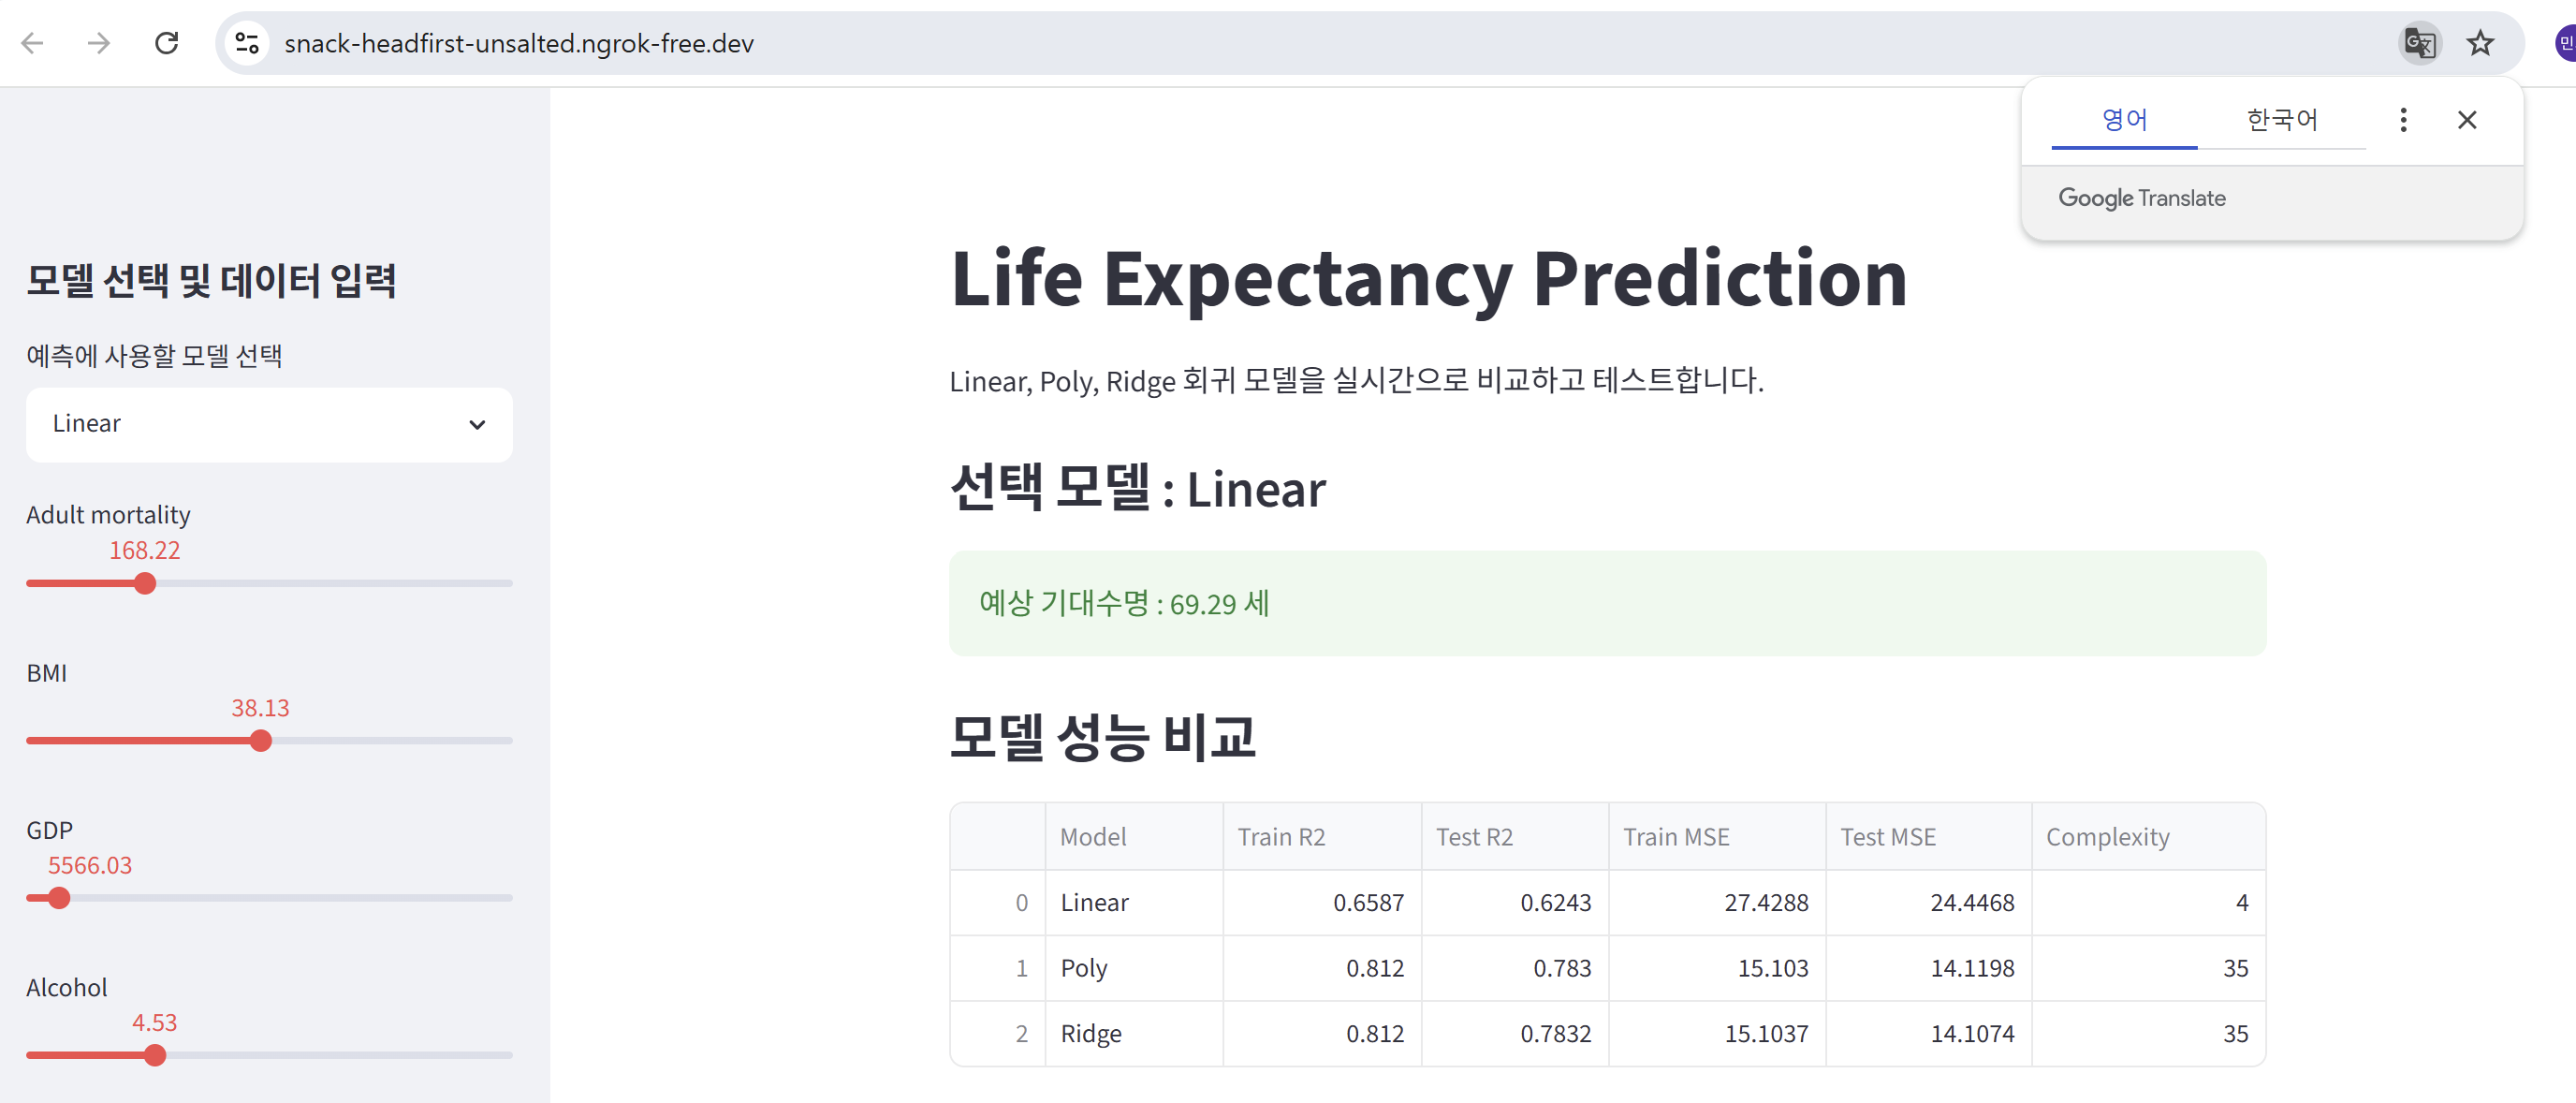

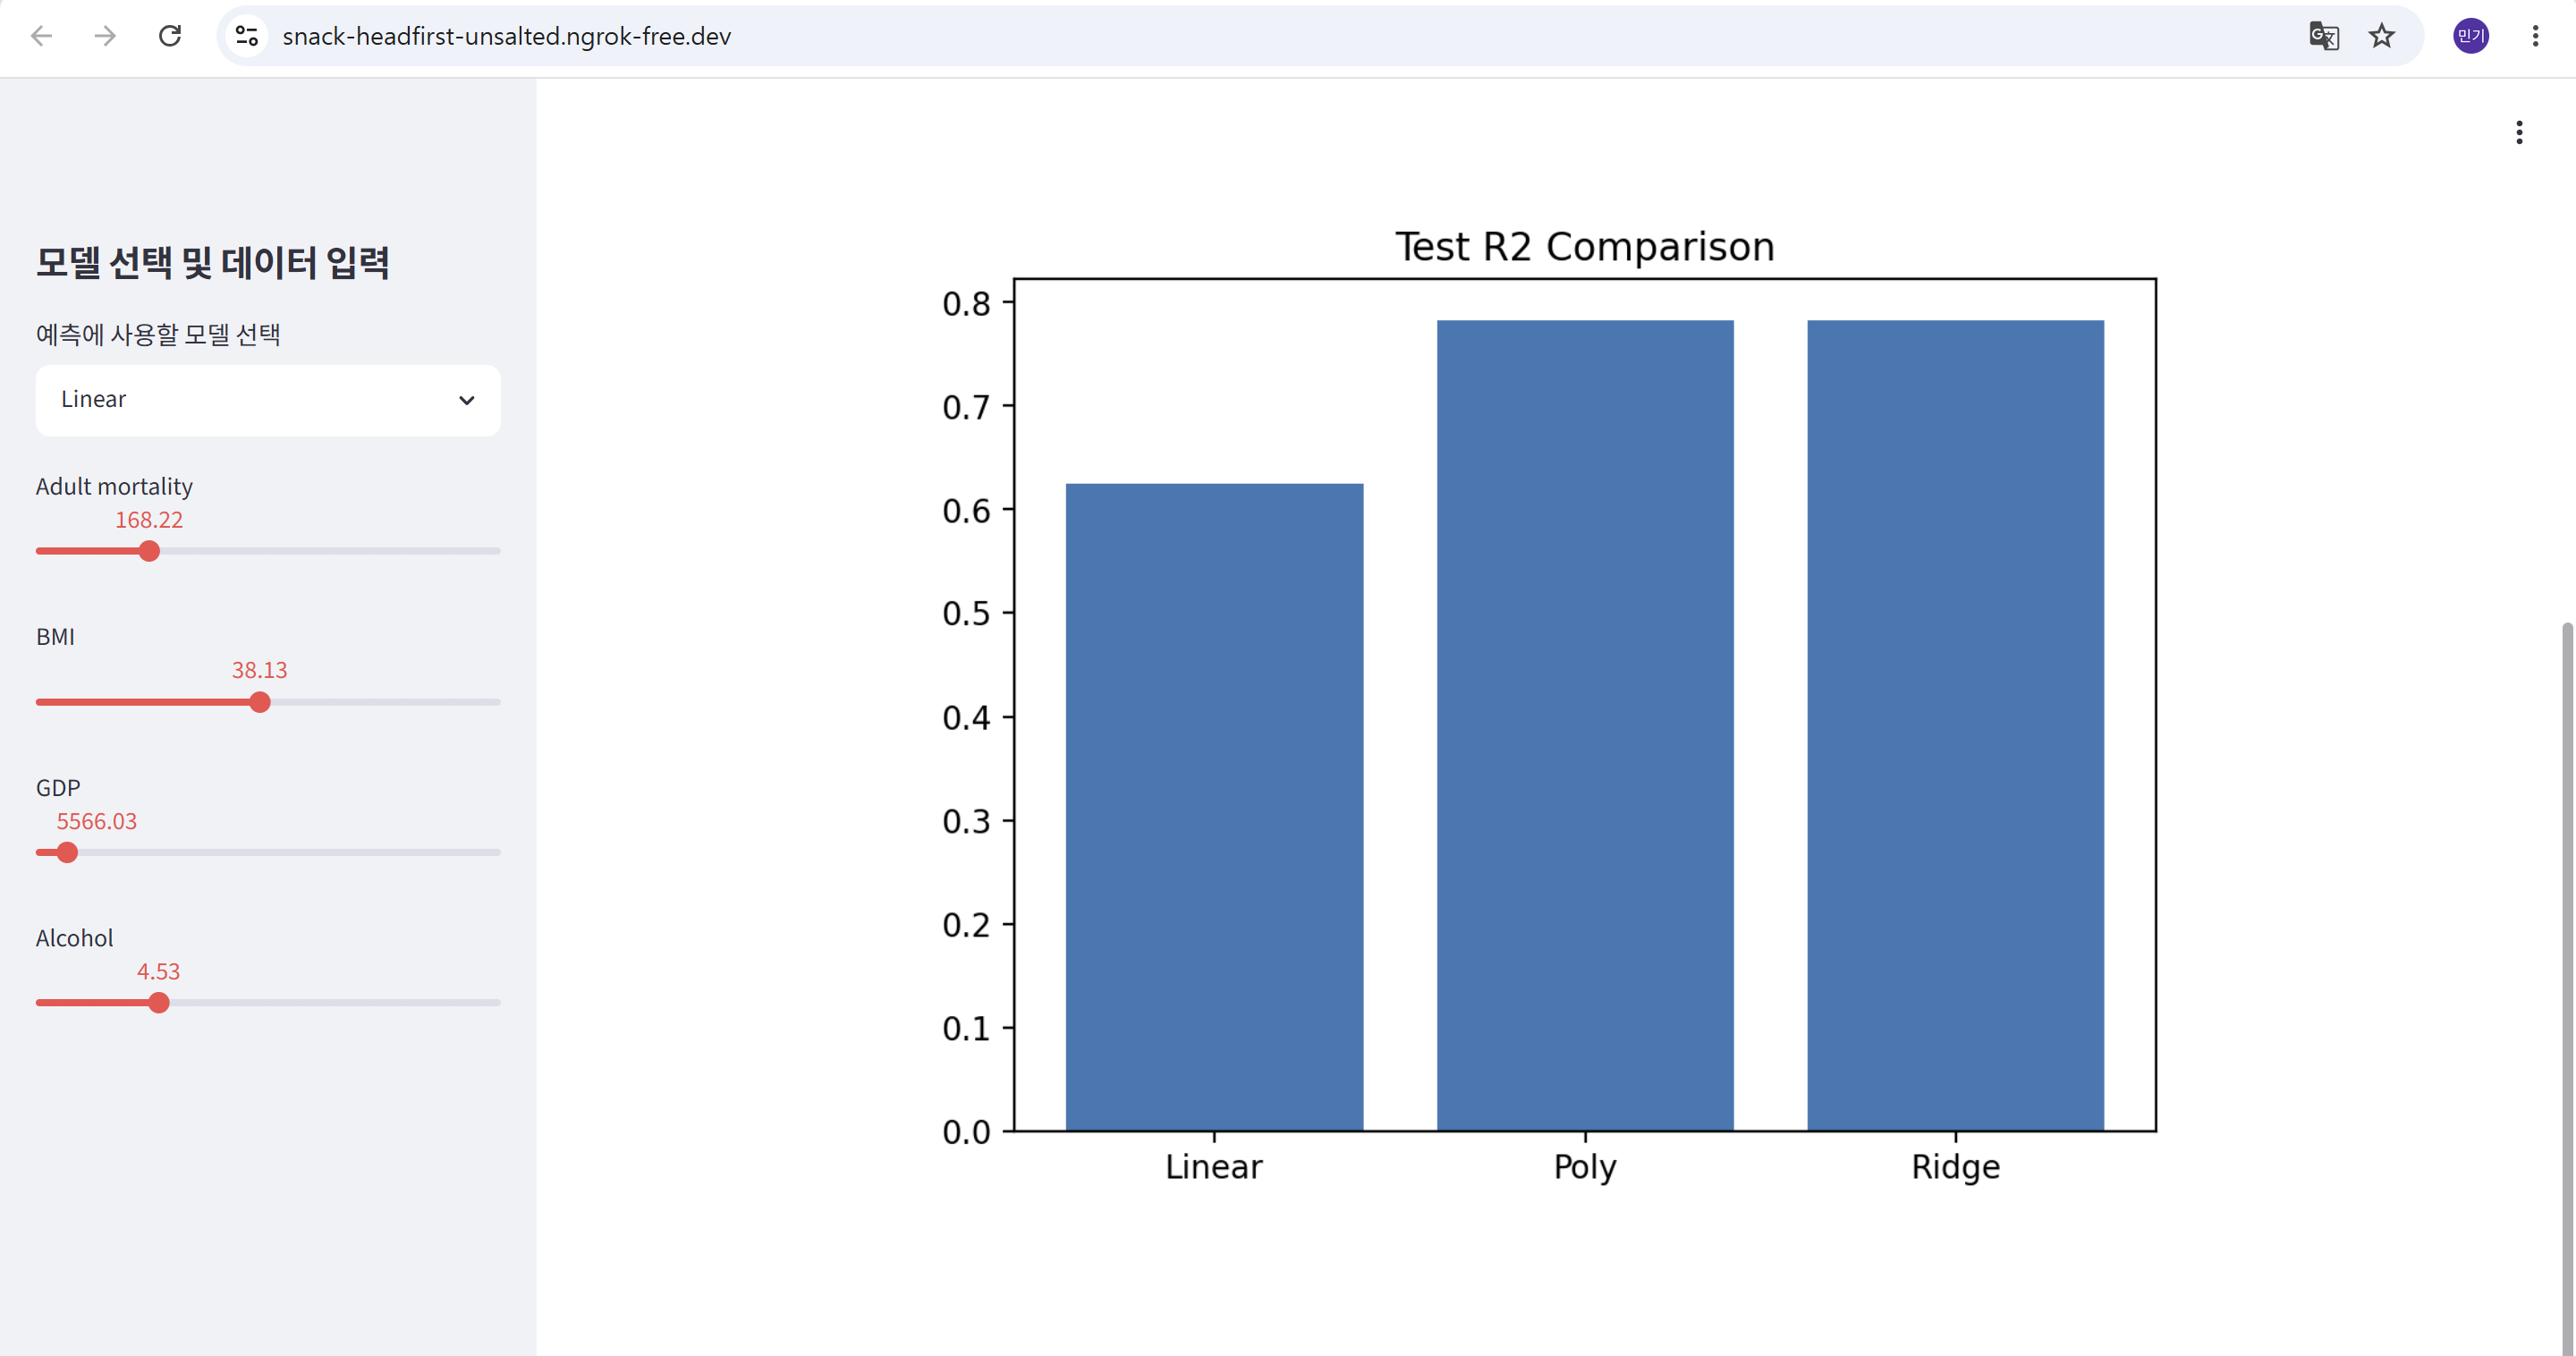